In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%pip install deepinv
import torch
import deepinv
from torchvision import datasets, transforms



# Overview

Given $x_0 \in \mathbb{R}^{H \times W \times C}$, where H is height of our image in pixel, W is the width in pixels, and C is the our color in RBG (so C is 3). For simplicity, we will just define $d = H \times W \times C$. $x_0$ represent our original image, and $X_0 \sim p(x)$, but we in reality we do not have access to what the probability function is. In diffusion models, we slowly corrupt our image by the process:

$$x_t = x_{t-1} + \sqrt{\beta} \epsilon, \text{where } \epsilon \in \mathbb{R}^d \text{ and } \epsilon \sim N(0,1)$$

Through this process, our image will eventually turn into random noise, and the main job of our model is to learn how to reverse this noise and turn pure noise into sensible images.

Note that our Normal distribution is multidimensional, and thus look is defined as:

$$N(\mu,\Sigma) = \frac{1}{\sqrt{(2\pi)^n |\Sigma|}} \exp\left(-\frac{1}{2}(x - \mu)^T \Sigma^{-1} (x - \mu)\right)$$

$$p(\epsilon) = N(\epsilon ; 0, I)$$
$$p(\sqrt{\beta}\epsilon) = N\left(\epsilon ; 0, \beta I\right)$$
$$p(x_1 - x_0) = N\left({x_1 - x_0} ; 0, \beta I\right)$$

If we now fixed our $x_0$, then

$$p(x_1|x_0) =  N\left(x_1; x_0, \beta I\right)$$


Thus, We can then define the PDF:

$$q(x_t | x_{t-1}) = N(x_t;x_0, t\beta I)$$

However, the problem with this is that it explodes our variance! Our main goal is to make it such that $$q(x_t | x_0) \xrightarrow{t \to \infty} \mathcal{N}(x_t;0, 1)$$

Let us then tweak our original transition model such that:

$$ x_{t} = \sqrt{1-\beta} x_{t-1} + \sqrt{\beta} \epsilon$$
$$ x_{t} = \sqrt{\alpha_t} x_{0} + \sqrt{(1-\alpha_t)}\epsilon, \text{ where } \alpha_t = (1-\beta)^t$$

Lets show this through a simple 1-d example:

In [ ]:
from scipy.stats import norm
from matplotlib.widgets import Slider

dx = 0.05
x = np.arange(-10,10, dx)
pdf1 = norm.pdf(x,-4,2)
pdf2 = norm.pdf(x,5,2)

X_0 = pdf1 + pdf2

probabilities = X_0 / np.sum(X_0)
sample_indices = np.random.choice(len(x), size=1000, p=probabilities)
samples = x[sample_indices]

fig, ax = plt.subplots()

ax.plot(x, X_0, label='X0', color='red', lw=2)
ax.plot(x, norm.pdf(x,0,1), label='N(0,1)', color='blue', lw=2)
ax.hist(samples, bins=40, density=True, alpha=0.7, label='x_0', color='gray')
plt.title("Diffusal Simulation")

t = 100
beta = 0.3
alpha_bar = (1 - beta)**t
noise = np.random.normal(0, 1, len(samples)) #sample 1 noise

new_sample = np.sqrt(alpha_bar) * samples + (1 - alpha_bar) * noise
ax.hist(new_sample, bins=50, density=True, alpha=0.4, label=f"x_{t}", color='blue')

ax.legend()
plt.show()



We saw from the example above that our process does converge to the normal distribution, and so $$\lim_{t \to \infty}q(x_t|x_0) = q(x_T|x_0) = N(x_t;0,I)$$

In reality however, we define our $\alpha_t$ to be:

$$\bar{\alpha}_t = \prod_{i=1}^t (1 - \beta_i) = \prod_{i=1}^t \alpha_i$$

Now let us define the reverse process that transform noise to images:

$$p(x_{t-1} | x_{t}; \theta) = p_\theta(x_{t-1} | x_{t})$$

While in the forward process all parameters are fixed, in the backward process we want to be able to find the best weights, $\theta$, to remove the noise most effectively. These weights are the weights in a Neural Network.

# Training

Like most things in machine learning, we want to maximize our likelihood function:

$$\mathcal{L}(\theta) = p(x_{t-1} | x_{t}; \theta)$$
$$L(\theta) = \log p(x_{t-1} | x_{t}; \theta)$$

In other words, we are trying to minimize the $- \log p(x_{t-1} | x_{t}; \theta)$. Also notice how we are not able to directly minimize $p(x_0 | x_T)$, and rather have to go through it step by step. This is because in the forward process, we knew exactly what we did to get from $x_t$ to $x_{t+1}$, and thus could jump to the conclusion to find $q(x_T | x_0)$. in the backward process, we are trying to denoise an image without knowing how it became noise in the first place, and thus we have to go step by step.


Let us now define a complete forward process using the joint probability:

$$q(x_1, x_2, ... , x_T| x_0) = q(x_1|x_0)\cdot q(x_2 | x_1, x_0)\cdot ... \cdot q(x_T | x_0, x_1, ..., X_{T-1})$$

and since each $x_t \to x_{t+1}$ is a markov process:

$$q(x_1, x_2, ... , x_T| x_0) = q(x_1|x_0)\cdot q(x_2 | x_1)\cdot ... \cdot q(x_T |X_{T-1})$$

We can also use the compact notation $q(x_{1:T} | x_0)$

$$q(x_{1:T} | x_0) = \prod_{t = 1}^T q(x_t | x_{t-1})$$

We can also do the same for the backward process:

$$p_\theta(x_{0:T}) = p_\theta(x_T) \prod_{t=1}^T p_\theta (x_{t-1} | x_t)$$

Since $p$ is joint probability, we can marginalize the distribution:

$$p_\theta(x_0) = \int p_\theta (x_{x_0:T}) dx_{1:T}  $$
$$- \log p_\theta(x_0) = -\log \int p_\theta (x_{x_0:T}) dx_{1:T}  $$

This is useful since it shows why we simply could not find $p(x_0| x_T)$, since it would require us to sum over all possible path from the noise to our desired image, which is simply impossible. However, we can still use it to approximate:

$$- \log p_\theta(x_0) = -\log \int q(x_{1:T} | x_0) \cdot \frac{p_\theta (x_{x_0:T})}{q(x_{1:T} | x_0)} dx_{1:T}  $$
$$- \log p_\theta(x_0) = -\log \mathbb{E}_{q(x_{1:T} | x_0)}\left[ \frac{p_\theta (x_{x_0:T})}{q(x_{1:T} | x_0)}\right] := -\log \mathbb{E}_q\left[ \frac{p_\theta (x_{x_0:T})}{q(x_{1:T} | x_0)}\right]$$

Using Jensen's Inequality and the fact that the negative log function is convex, we know that:

$$- \log p_\theta(x_0) \leq \mathbb{E}_q\left[- \log \frac{p_\theta (x_{x_0:T})}{q(x_{1:T} | x_0)}\right]$$

This is what we call the upperbound of our negative log likelihood, which we call the Evidence Lower Bound (ELBO).

Without going through all the computation, that expression is equivalent to:


$$\mathbb{E}_{q}\left[
\underbrace{D_{\mathrm{KL}}\!\left(q(x_T \mid x_0) \,\|\, p(x_T)\right)}_{\text{Does not depend on } \theta}
+ \sum_{t>1} D_{\mathrm{KL}}\!\left(q(x_{t-1} \mid x_t, x_0) \,\|\, p_{\theta}(x_{t-1} \mid x_t)\right)
- \underbrace{\log p_{\theta}(x_0 \mid x_1)}_{\text{Negligible}}
\right]$$


Since we are training our model based on $\theta$, and the last term is the expected value of $p_\theta(x_0|x_1)$ is extremely small, we can just ignore both the first and last term. Thus, we are mainly focus with training using the following:

$$\approx \mathbb{E}_{q}\left[
\sum_{t>1} D_{\mathrm{KL}}\!\left(q(x_{t-1} \mid x_t, x_0) \,\|\, p_{\theta}(x_{t-1} \mid x_t)\right)
\right]$$


The amazing thing is that $q(x_{x-1}|x_t,x_0)$ actually has a close form expression, and represent a "perfect" reversal process, we can compare $p_\theta$ to it. Specifically:

$$x_{x-1}|x_t,x_0 \sim N(\tilde{\mu}_t, \tilde{\beta}_t)$$

$$\tilde{\mu}_t(x_t, x_0) = \frac{\sqrt{\bar{\alpha}_{t-1}}}{1 - \bar{\alpha}_t} x_0 + \frac{\sqrt{\alpha_t}(1 - \bar{\alpha}_{t-1})}{1 - \bar{\alpha}_t} x_t$$

We can reparameterized, however:

$$\tilde{\mu}_t(x_t, \epsilon) =
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t
-
\frac{\beta_t}{\sqrt{1-{\alpha}_t}}\,\epsilon
\right)$$

$$\tilde{\beta}_t
=
\frac{1-{\alpha}_{t-1}}{1-{\alpha}_t}\,\beta_t$$

We want to make our $p_\theta$ to be as close to $q$ as possible, and thus reduce the KL-Divergence. We will pick $p_\theta$ to be a Gaussian since the reverse of a Gaussian Markov Chain is also Gaussian:

$$p_\theta(x_{t-1}|x_t) = N(x_{t-1}; \mu_\theta, \sigma_t I)$$


By choosing this formulation, our Loss fuction reduces nicely to:

$$ \mathbb{E}_{q(x_t|x_0)} \left[ \sum_{t>1}\frac{1}{2\sigma_t^2 }\|\tilde{\mu}_t (x_t,x_0) - \mu_\theta(x_t,t)\|^2 \right]$$

$$\mu_\theta (x_t, t) = 
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t
-
\frac{\beta_t}{\sqrt{1-{\alpha}_t}}\,\epsilon_\theta(x_t, t)
\right)$$


Here, $\epsilon_\theta({x}_t, t) \in \mathbb{R}^d$ is the output of our neural network that represents the model's guess of the noise that was added to the original image. You can also notice how its identical to $\tilde{\mu}_t$ beside our $\epsilon$ term. Thus we only want the model to learn the true noise instead of the true mean for simplicity. 

Also notice how $q(x_{1:T}|x_0) \to q(x_t|x_0)$. This is due to the fact that the terms inside the EV, which we'll call $f(x_t)$, only depends on $x_t$: 

$$\mathbb{E}_{q(x_{1:T}|x_0)}[f(x_t)] = \int \int ... \int q(x_{1:T}|x_0) \cdot f(x_t)  \ dx_1dx_2 ... dx_T$$
$$= \int  f(x_t) \left[\int ... \int q(x_{1:T}|x_0)  \ dx_1dx_2 ... dx_{t-1} dx_{t+1} ... dx_T \right]dx_t$$
$$= \int  f(x_t) q(x_t| x_0)dx_t$$
$$= E_{q(x_t|x_0)}[f(x_t)]$$




Plugging $\tilde{\mu_t}(x_t, \epsilon) $ and $\mu_\theta(\sqrt{\bar{\alpha}_t} \mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t} \boldsymbol{\epsilon},t)$ into our equation, we get:

$$Loss(\theta)
=
\mathbb{E}_{x_0,\epsilon}\!\left[
\sum_{t>1}
\frac{\beta_t^{2}}{2\sigma_t^{2}\alpha_t(1-\bar{\alpha}_t)}
\,
\left\lVert
\epsilon - \epsilon_{\theta}(\sqrt{\bar{\alpha}_t} \mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t} \boldsymbol{\epsilon},t)
\right\rVert^{2}
\right]$$

Also notice how we changed $\mathbb{E}_{q(x_t|x_0)} \to \mathbb{E}_{x_0,\epsilon}$. We're allowed to do this since $x_t$ can be expressed in term $\epsilon$. Recall the following:

$$x_t \sim q(x_t| x_0)$$
$$x_t = \sqrt{\bar{\alpha}_t} \mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t} \boldsymbol{\epsilon}$$

We can thus write our expectation as $\mathbb{E}_{q(x_t|x_0)} (f(x_t))$, where $x_t = h(\epsilon)$. By LOTUS, we can thus rewrite it as:

$$\mathbb{E}_{q(x_t|x_0)} [f(x_t)] = \mathbb{E}_{\epsilon}[f(h(\epsilon))]$$

This does not give us a single value however, but rather gives us a function that depends on $x_0$. Rather, we want an average Loss for each $x_0 \sim q(x_0)$, so we choose to average our loss over many $x_0$ values. Since $x_0$ and $\epsilon$ are independent, we can rewrite it as:

$$ Loss(\theta) =

\mathbb{E}_{x_0} \left[

\mathbb{E}_{\epsilon}\!\left[
\sum_{t>1}
\frac{\beta_t^{2}}{2\sigma_t^{2}\alpha_t(1-\bar{\alpha}_t)}
\,
\left\lVert
\epsilon - \epsilon_{\theta}(\sqrt{\bar{\alpha}_t} \mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t} \boldsymbol{\epsilon},t)
\right\rVert^{2}
\right]
\right]

=
\mathbb{E}_{x_0,\epsilon}\!\left[
\sum_{t>1}
\frac{\beta_t^{2}}{2\sigma_t^{2}\alpha_t(1-\bar{\alpha}_t)}
\,
\left\lVert
\epsilon - \epsilon_{\theta}(\sqrt{\bar{\alpha}_t} \mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t} \boldsymbol{\epsilon},t)
\right\rVert^{2}
\right]$$

To save space and make things easier to read, let us define $\epsilon_\theta$ henceforth as:

$$\epsilon_{\theta} := \epsilon_{\theta}(\mu_\theta(\sqrt{\bar{\alpha}_t} \mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t} \boldsymbol{\epsilon},t))$$
$$C_t := \frac{\beta_t^2}{2\sigma_t^2 \alpha_t(1-\bar{\alpha})}$$

Computationally, summing over all $t$ values is not the most efficient, so we instead choose to a random $t \sim \text{Uniform}(1,T)$ for each of our sample:

$$Loss(\theta)
=
\mathbb{E}_{{x_0,\epsilon, t}}\!\left[
C_t \cdot
\left\lVert
\epsilon - \epsilon_{\theta}
\right\rVert^{2}
\right]$$

In the actual DDPM paper however, the author decided to set $C_t$ to 1:

$$L_{Simple}(\theta)
=
\mathbb{E}_{{x_0,\epsilon, t}}\!\left[

\,
\left\lVert
\epsilon - \epsilon_{\theta}
\right\rVert^{2}
\right]$$

When we take the gradient of it:

$$\nabla L_{Simple}(\theta)
=
\mathbb{E}_{{x_0,\epsilon, t}}\!\left[
\,
\nabla
\left\lVert
\epsilon - \epsilon_{\theta}
\right\rVert^{2}
\right]$$

The norm is also defined such that:

$$\|\epsilon - \epsilon_\theta\|^2 = \sum_{i \in d} (\epsilon_i - \epsilon_{\theta,i})^2$$


The training algorithm goes as follow:

1. pick $x_0 \sim q(x_0), \epsilon \sim N(0, I), t \sim \text{Uniform}(1, T)$
2. Scale each element in $x_0$ to between $[-1,1]$ 
2. Compute $\mathbf{x}_t = \sqrt{\bar{\alpha}_t} \mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t} \boldsymbol{\epsilon}$
3. Compute the neural network $\epsilon_\theta(x_t, t)$
4. Compute the $Loss$ function
5. Compute $\nabla_\theta \|\epsilon - \epsilon_\theta\|^2$ and minimize it.
6. Repeat 1-5 until the Loss value converges.


The image-producing algorithm goes as follow:
1. pick $x_T \sim N(0,I)$
2. For $t = T, ..., 1$:
    1. pick $z \sim N(0,I)$ if $t > 1$, else $z=0$
    2. Compute $x_{t-1} = \mu_\theta(x_t,t) + \sigma_t z$
3. Convert $x_0 \mapsto \text{round} \left(\frac{x_0 + 1}{2}\cdot 255 \right)$, where each operation is piecewise.

Notice that for $t=1$, $z$ is set $0$ since it is the final step to denoising our image. In other words, we do not want to add additional noise to our final image; we want a clean one.

In a Gaussian, pixel values are continuous, but thats not the case for us. Each pixel channel takes on a discrete value from $\{0,1,...,255\}$. To reconcile this difference, we scale it to between $[-1,1]$, where each discrete value occupy an equal space within this interval.

We are actually still interested in finding the distribution $p_\theta(x_0|x_1)$, and afterward we can sample its mean to get our final infered image. The problem however is that $p_\theta(x_0|x_1)$ gives us the probability density, not the probability itselfs. We resolves this by defining $p_\theta$ pixel wise:

$$p_\theta(x_0^i;x_1) = N(x_0^i; \mu_\theta^i(x_1, 1), \sigma_0^i)$$

Each $x_0^i$ alone gives us the density, but we want to discretize our probability. Let $i$ correspond to a specific pixel channel element within our image $x_0$:

$$p_\theta(v;x_1) := \int_{\delta_{-}(v)}^{\delta_+(v)}N(x; \mu_\theta^i(x_1, 1), \sigma_1^2) dx$$

Where $v\in [-1,1]$. The $\delta$ is used to collect the probability for the pixel value in its given bin:

$$\delta_{+}(v) = \begin{cases} \infty & \text{if } v = 1 \\ v + \frac{1}{255} & \text{if } v < 1 \end{cases} \quad \delta_{-}(v) = \begin{cases} -\infty & \text{if } v = -1 \\ v - \frac{1}{255} & \text{if } v > -1 \end{cases}$$

The probability of the whole image is thus given as:

$$p_\theta(x_0;x_1) := \prod_{i=1}^d \int_{\delta_{-}(x_0^i)}^{\delta_+(x_0^i)}N(x; \mu_\theta^i(x_1, 1), \sigma_1^2) dx$$

This formulation of $p_\theta$ defines the proper probabilistic final decoder for training / likelihood on discrete pixels. Instead of sampling from the decoder, the paper decides to output $x_0 = \mu_\theta (x_1,1)$ since it gives a cleaner reconstruction and avoids adding unnecessary final-step noise. Another method would be to find the exact $x_0$ that maximizes our discretized $p_\theta(x_0|x_1)$ function.

In [ ]:
#Set up and hyperparameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 250
image_size = 32
lr = 1e-4
epochs = 10

#Math constants
betas = torch.linspace(0.0001, 0.02, 1000, device=device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

transform = transforms.Compose(
    [
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.0,), (1.0,))
    ]
)

train_loader = torch.utils.data.DataLoader(
    datasets.MNIST(root="./data", train=True, download=True, transform=transform),
    batch_size=batch_size,
    shuffle=True,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True
)

model = deepinv.models.DiffUNet(in_channels=1, out_channels=1, pretrained=None).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
mse = deepinv.loss.MSE(reduction='mean')

for epoch in range(epochs):
    model.train()
    for batch_idx, (data, _) in enumerate(train_loader):
        imgs = data.to(device, non_blocking=True) #Selecting our x_0
        noise = torch.randn_like(imgs) #Selecting our epsilon
        t = torch.randint(0, 1000, (imgs.size(0),), device=device) #Selecting our times

        noised_imgs = (
            sqrt_alphas_cumprod[t, None, None, None] * imgs
            + sqrt_one_minus_alphas_cumprod[t, None, None, None] * noise
        )

        optimizer.zero_grad()
        estimated_noise = model(noised_imgs, t, type_t="timestep")
        loss = mse(estimated_noise, noise)
        loss.backward()
        optimizer.step()

        print(f"Epoch: {epoch}, Batch: {batch_idx}, Loss: {loss.item()}")

torch.save(
    model.state_dict(),
    "trained_diffusion_model.pth",
)
print("Successfully saved!")

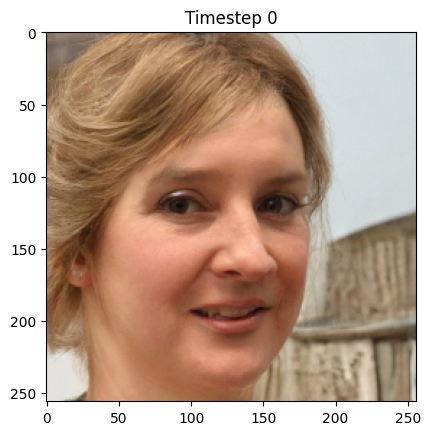

In [157]:
from IPython import display
from torchvision.utils import make_grid
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = deepinv.models.DiffUNet(in_channels=3, out_channels=3, pretrained="download").to(device) #Pretrained image
#weights = torch.load("trained_diffusion_model.pth", map_location=device)
#model.load_state_dict(weights)

model.eval()

n_samples = 1

with torch.no_grad():
    x = torch.randn(n_samples, 3, 256, 256).to(device)

    for t in reversed(range(1000)):
        t_tensor = torch.ones(n_samples, device=device).long() * t

        output = model(x, t_tensor, type_t="timestep")
        predicted_noise = output[:, :3, :, :]

        alpha = alphas[t]
        alpha_cumprod = alphas_cumprod[t]
        beta = betas[t]

        if t > 0:
            noise = torch.randn_like(x)
        else:
            noise = 0

        x = (1 / torch.sqrt(alpha)) * (
            x - (beta / torch.sqrt(1 - alpha_cumprod)) * predicted_noise
        ) + torch.sqrt(beta) * noise

        if t % 25 == 0:
            display.clear_output(wait=True)
            img = x[0].permute(1, 2, 0).cpu()
            img.squeeze()

            grid = make_grid(
                img,
                normalize=True,
                value_range=(img.min(), img.max()),   # or (img.min().item(), img.max().item())
                scale_each=False       # keep one global scaling across channels/images
            )


            plt.imshow(grid)
            plt.title(f"Timestep {t}")
            plt.show()